## 야후 파이넨스(yfinance)
- yfinance는 전 세계 주식, ETF, 암호화폐의 실시간 및 과거 데이터를 코드 한 줄로 내 파이썬 노트북에 가져와 주는 "무료 금융 데이터 치트키" 라이브러리 입니다.
- 기존에 사이트에서 CSV파일을 다운로드 할 수 있지만, 종목이 많아지면 관리하기 어렵기 떄문에 라이브러리 사용을 권장합니다.

[야후 파이넨스 공식 링크](https://finance.yahoo.com/)

In [56]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

warnings.filterwarnings('ignore')

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 맥 애플고딕 설정
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [46]:
session = cffi_requests.Session(impersonate="chrome")
tickers = ["JEPQ", "JEPI", "NVDA", "MSFT"]
all_data = {}

for t in tickers:
    df = yf.download(t, start="2024-01-01", end="2026-09-01", session=session, threads=False)
    all_data[t] = df
    time.sleep(5)

all_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


{'JEPQ': Price           Close       High        Low       Open   Volume
 Ticker           JEPQ       JEPQ       JEPQ       JEPQ     JEPQ
 Date                                                           
 2024-01-02  37.038414  37.195324  36.920357  37.195324  3137400
 2024-01-03  36.776890  36.920349  36.732057  36.881497  2316600
 2024-01-04  36.627445  36.874018  36.612501  36.664804  2790100
 2024-01-05  36.724598  36.896452  36.612518  36.642406  2798000
 2024-01-08  37.284988  37.292459  36.806782  36.814255  2124500
 ...               ...        ...        ...        ...      ...
 2026-08-25  59.072330  59.220631  58.849884  59.092104  4602500
 2026-08-26  59.111877  59.210742  58.924030  58.943804  4441800
 2026-08-27  59.625980  59.643774  59.279948  59.448022  4667600
 2026-08-28  59.467796  59.823710  59.388702  59.586434  6185300
 2026-08-31  59.537003  59.566661  59.319497  59.467797  8095700
 
 [668 rows x 5 columns],
 'JEPI': Price           Close       High        Low   

In [21]:
all_data["NVDA"].head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.028793,49.152535,47.457451,49.101684,411254000
2024-01-03,47.431519,48.044739,47.183238,47.347762,320896000
2024-01-04,47.859283,48.359832,47.370698,47.628948,306535000
2024-01-05,48.955109,49.403809,48.166394,48.321945,415039000
2024-01-08,52.101990,52.123929,49.336008,49.368914,642510000


In [22]:
all_data["NVDA"].columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

# 데이터준비

In [23]:
close_df = pd.DataFrame()

for t in tickers:
    close_df[t] = all_data[t]["Close"]

print(close_df)

                 JEPQ       JEPI        NVDA        MSFT
Date                                                    
2024-01-02  37.038414  44.692707   48.028793  363.117920
2024-01-03  36.776890  44.441338   47.431519  362.853577
2024-01-04  36.627445  44.425125   47.859283  360.249146
2024-01-05  36.724598  44.392693   48.955109  360.063110
2024-01-08  37.284988  44.692707   52.101990  366.858063
...               ...        ...         ...         ...
2026-08-25  59.072330  57.764870  212.811874  491.709991
2026-08-26  59.111877  57.784740  209.425659  496.369995
2026-08-27  59.625980  57.476738  227.725174  505.059998
2026-08-28  59.467796  57.417130  217.306839  513.530029
2026-08-31  59.537003  57.128998  220.533234  507.290009

[668 rows x 4 columns]


# 데이터 전처리

In [24]:
close_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 668 entries, 2024-01-02 to 2026-08-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   JEPQ    668 non-null    float64
 1   JEPI    668 non-null    float64
 2   NVDA    668 non-null    float64
 3   MSFT    668 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [25]:
close_df.describe()

,JEPQ,JEPI,NVDA,MSFT
count,668.000000,668.000000,668.000000,668.000000
mean,47.879984,51.286076,147.299539,431.921961
std,6.121774,3.362890,43.831636,44.189093
min,36.627445,44.392693,47.431519,350.446106
25%,42.768600,48.528732,115.916487,400.006989
50%,47.085598,51.441776,141.016617,417.746292
75%,53.268997,54.248923,183.702614,470.046608
max,59.873146,57.784740,235.202393,537.646423


# 초기 가설
- NVDA, MSFT 개별 성장주이기 때문에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄 것이다.
- JEPQ, JEPI 배당형 성장형 ETF이기 때문에 수익률이 낮고, 상승기가 낮더라도 시장의 조정기마다 고점 대비 자산이 깎이는 낙폭이 낮았을 것이다.
- 2024년 조정기에 ETF중 표준편차가 낮은 JEPI가 방어력이 가장 좋았을 것이다.

In [28]:
# pct_change() : 변화율을 구해주는 함수
# ex) (오늘 종가 - 어제 종가) / 어제종가
returns_off = close_df.pct_change().dropna()
returns_off

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007061,-0.005624,-0.012436,-0.000728
2024-01-04,-0.004064,-0.000365,0.009019,-0.007178
2024-01-05,0.002652,-0.000730,0.022897,-0.000516
2024-01-08,0.015259,0.006758,0.064281,0.018872
2024-01-09,0.002204,-0.000726,0.016975,0.002936
...,...,...,...,...
2026-08-25,0.005554,0.000861,0.021921,0.009029
2026-08-26,0.000669,0.000344,-0.015912,0.009477
2026-08-27,0.008697,-0.005330,0.087380,0.017507


In [32]:
# cumprod() 
cum_returns_off = (1 + returns_df).cumprod() - 1
cum_returns_off

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007061,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011096,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006713,0.019287,-0.008413
2024-01-08,0.006657,0.000000,0.084807,0.010300
2024-01-09,0.008876,-0.000726,0.103222,0.013266
...,...,...,...,...
2026-08-25,0.594894,0.292490,3.430923,0.354133
2026-08-26,0.595961,0.292934,3.360419,0.366966
2026-08-27,0.609842,0.286043,3.741430,0.390898


In [36]:
# cummax: 이전 값과 비효하여 최고 값으로 대체
peak_df = close_df.cummax()
peak_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,37.038414,44.692707,48.028793,363.117920
2024-01-03,37.038414,44.692707,48.028793,363.117920
2024-01-04,37.038414,44.692707,48.028793,363.117920
2024-01-05,37.038414,44.692707,48.955109,363.117920
2024-01-08,37.284988,44.692707,52.101990,366.858063
...,...,...,...,...
2026-08-25,59.873146,57.764870,235.202393,537.646423
2026-08-26,59.873146,57.784740,235.202393,537.646423
2026-08-27,59.873146,57.784740,235.202393,537.646423


In [37]:
# 고점 대비 낙폭
drawdown_df = (close_df - peak_df) / peak_df
drawdown_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,0.000000,0.000000,0.000000,0.000000
2024-01-03,-0.007061,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011096,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006713,0.000000,-0.008413
2024-01-08,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2026-08-25,-0.013375,0.000000,-0.095197,-0.085440
2026-08-26,-0.012715,0.000000,-0.109594,-0.076772
2026-08-27,-0.004128,-0.005330,-0.031791,-0.060609


In [42]:
# 수익의 변동성(표준편차) + 미국 주식(252) - 휴장일을 제외한 미국의 주식 일수
# 252일 동안에 얼만큼에 변동성이 있는가? 를 구하는 것 : 연율화 구하기(미국 주식의 년 단위 변동성)
annual_vol = returns_df.std() * np.sqrt(252)
annual_vol

mdd = drawdown_df.min()
mdd

v1_proof = pd.DataFrame({
    "최종 누적 수익률(%)": cum_returns_off.iloc[-1] * 100,
    "연율화 변동성(%)": annual_vol * 100,
    "최대 낙폭 MDD(%)": mdd * 100
})

v1_proof

,최종 누적 수익률(%),연율화 변동성(%),최대 낙폭 MDD(%)
JEPQ,60.743931,16.137058,-20.069917
JEPI,27.826219,10.279552,-13.257860
NVDA,359.168799,48.437023,-36.881033
MSFT,39.703931,26.850655,-34.498398


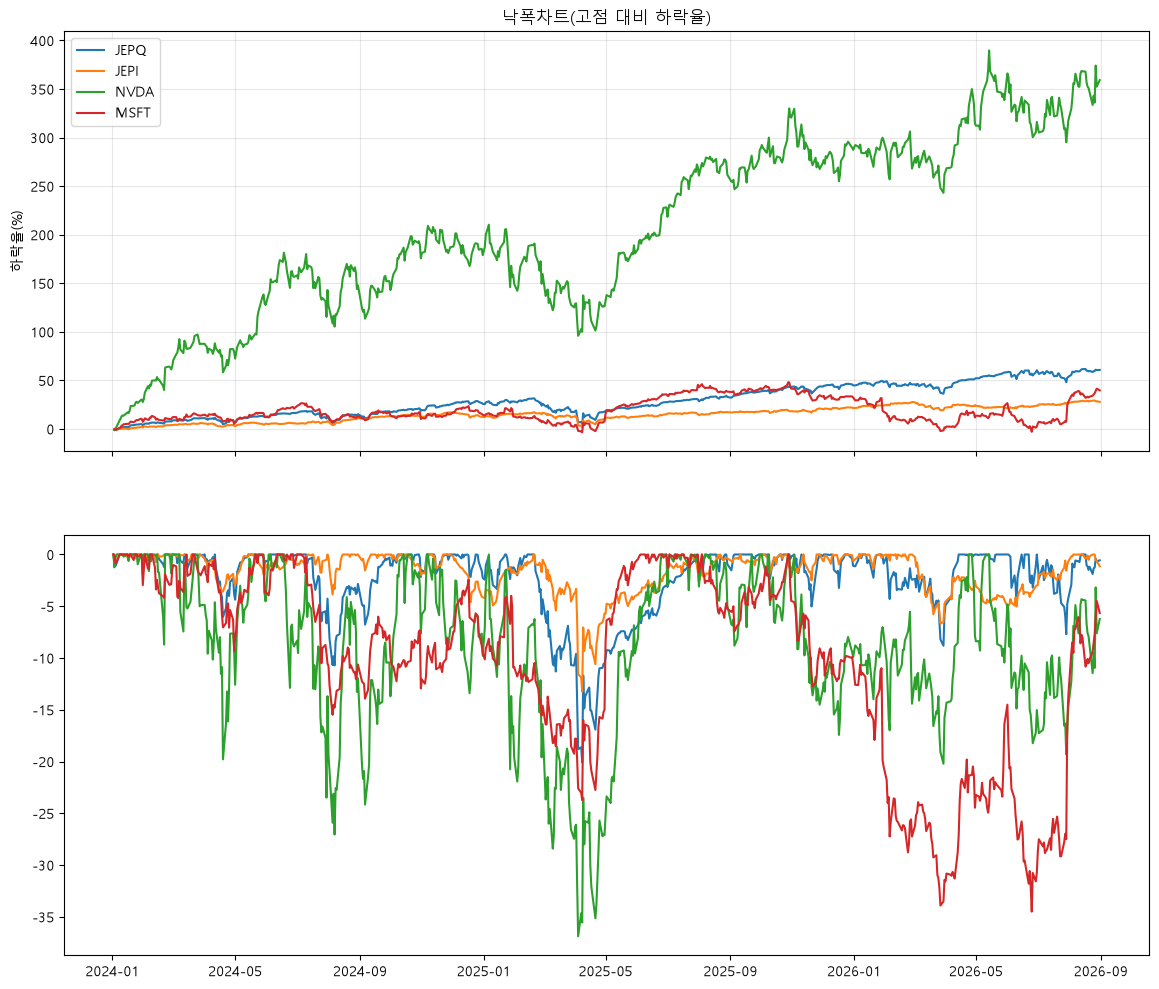

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(14,12), sharex=True)

for t in tickers:
    axes[0].plot(cum_returns_off.index, cum_returns_off[t] * 100, label=t)
    
    axes[0].set_title("자산별 누적 수익률(2024-2026)")
    axes[0].set_ylabel("누적 수익률(%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


for t in tickers:
    axes[1].plot(drawdown_df.index, drawdown_df[t] * 100, label=t)

    axes[0].set_title("낙폭차트(고점 대비 하락율)")
    axes[0].set_ylabel("하락율(%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

plt.show()

- NVDA, MSFT 개별 성장주이기 때문에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄 것이다.
- JEPQ, JEPI 배당형 성장형 ETF이기 때문에 수익률이 낮고, 상승기가 낮더라도 시장의 조정기마다 고점 대비 자산이 깎이는 낙폭이 낮았을 것이다.
- 2024년 조정기에 ETF중 표준편차가 낮은 JEPI가 방어력이 가장 좋았을 것이다.

>>>>>

NVDA, MSFT 개별 성장주는 각각 36.8%, 34.4%의 최고 하락률을 기록하고 있지만, 반면 JEPI ETF는 최대 하락률이 13.2%로 2.8배 가량 차이가 난다. 
JEPI는 주가 하락의 방어가 가장 좋은 ETF주식이다. 
>>> 가설은 참.

## 가설2
- JEPQ, JEPI 배당형ETP
- JEPQ는 나스닥 100 기반으로 상장된 ETF NVDA, MSFT와 높은 상관관계를 가질 것이다.
- JEPI는 S&P 500 기반으로 상장된 ETF이므로, NVDA, MSFT와 낮은 상관관계를 가질 것이다.

In [73]:
# .rolling()
rolling_jpei = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPI"])
rolling_jpeq = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPQ"])

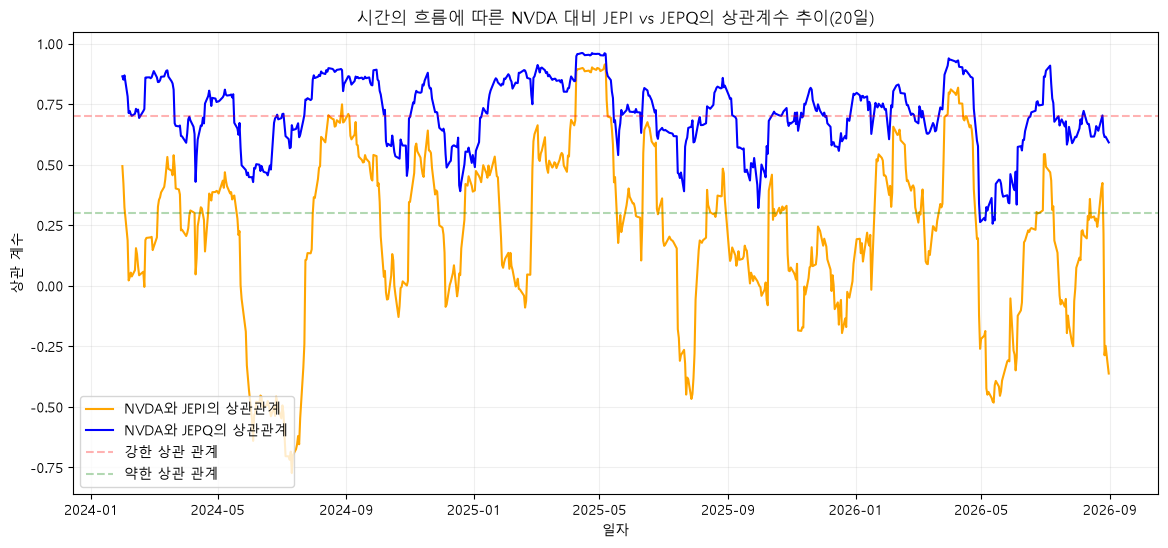

In [95]:
plt.figure(figsize=(14, 6))
plt.plot(rolling_jpei.index, rolling_jpei, label="NVDA와 JEPI의 상관관계", color="orange")
plt.plot(rolling_jpeq.index, rolling_jpeq, label="NVDA와 JEPQ의 상관관계", color="blue")

plt.axhline(0.7, color="red", linestyle="--", alpha=0.3, label="강한 상관 관계")
plt.axhline(0.3, color="green", linestyle="--", alpha=0.3, label="약한 상관 관계")

plt.title("시간의 흐름에 따른 NVDA 대비 JEPI vs JEPQ의 상관계수 추이(20일)")
plt.ylabel("상관 계수")
plt.xlabel("일자")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.2)
plt.show()

# 가설 검증 결과
- JPEQ와 NVDA는 지속적 0.7이상의 높은 상관관계를 유지하며 동조화가 잘 되고 있다.
- 반대로 JEPI는 NVDA와의 상관관계가 0.4이상의 낮은 상관관계를 유지하며 동조화가 되고 있다.
- 성장주(NVDA) 리스크의 분산을 하고 싶을 때에는 JEPI를 추천해야한다.
- 가설은 참.

# EDA시각화
역사적 고점 대비 대략 20%가 떨어졌을 떄 사면, 이후 한달 뒤에 얼마정도의 수익을 볼 확률, 평균 수익률은 어떻게 될까?

In [116]:
forward_days = 20
results = []

for t in tickers:
    # 20일 뒤 주가 / 현재 주가 - 1(20일동안의 수익율)
    fwd_return_df = (close_df[t].shift(-forward_days) / close_df[t]) - 1
    drawdown = drawdown_df[t]
    df_temp = pd.DataFrame({"Drawdown": drawdown, "FwdReturn": fwd_return_df}).dropna()

    # 구간
    bins = [-1.0, -0.2, -0.1, -0.05, 0.001]
    labels = ["-20% 이하(대폭락)", "-10% ~ -20%", "-5% ~ -10%", "-0% ~ -5%"]

    df_temp["구간"] = pd.cut(df_temp["Drawdown"], bins=bins, labels=labels)

    # 구간별 통계 집계
    for label in labels:
        sub_df = df_temp[df_temp["구간"] == label]

        if len(sub_df) > 0:
            win_rate = (sub_df["FwdReturn"] > 0).mean() * 100 # 수익을 볼 확률(%)
            avg_rate = sub_df["FwdReturn"].mean() * 100 # 평균 수익률(%)

            results.append({
                "종목": t,
                "낙폭 구간": label,
                "진입 횟수(일)": len(sub_df),
                "1개월 뒤 승률(%)": win_rate,
                "1개윌 뒤 평균 수익률(%)": avg_rate
            })

prob_df = pd.DataFrame(results)
prob_df

,종목,낙폭 구간,진입 횟수(일),1개월 뒤 승률(%),1개윌 뒤 평균 수익률(%)
0,JEPQ,-20% 이하(대폭락),1,100.000000,13.484022
1,JEPQ,-10% ~ -20%,27,77.777778,3.940411
2,JEPQ,-5% ~ -10%,80,78.750000,2.140767
3,JEPQ,-0% ~ -5%,540,73.518519,1.201905
4,JEPI,-10% ~ -20%,4,100.000000,8.186330
5,JEPI,-5% ~ -10%,23,95.652174,2.954739
6,JEPI,-0% ~ -5%,621,70.531401,0.660211
7,NVDA,-20% 이하(대폭락),63,66.666667,9.943814
8,NVDA,-10% ~ -20%,176,73.863636,4.830249
9,NVDA,-5% ~ -10%,169,45.562130,0.567435


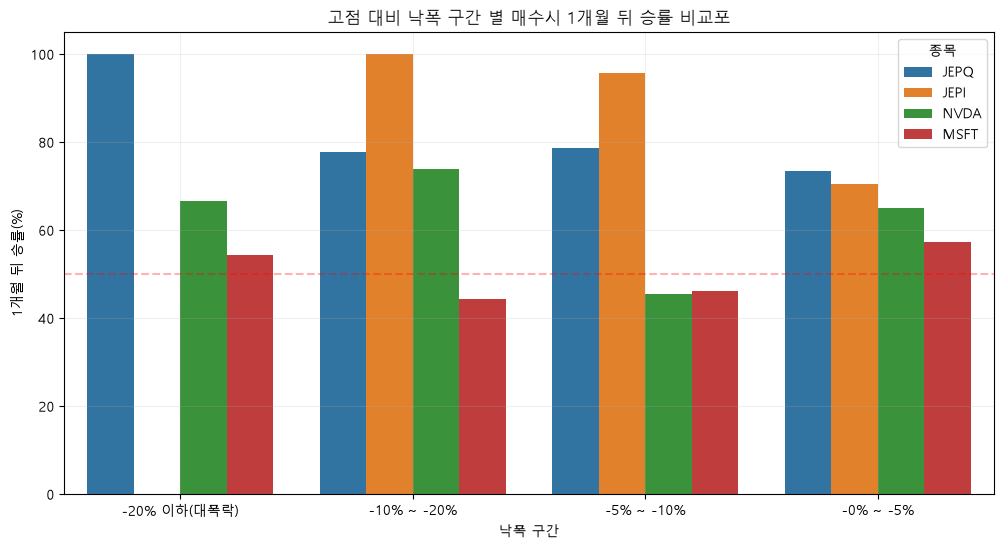

In [123]:
plt.figure(figsize=(12,6))
sns.barplot(data=prob_df, x="낙폭 구간", y="1개월 뒤 승률(%)", hue="종목")

plt.axhline(50, color="red", linestyle="--", alpha=0.3)

plt.title("고점 대비 낙폭 구간 별 매수시 1개월 뒤 승률 비교포")
plt.grid(True, alpha=0.2)
plt.show()

## 결론
- 개별 성장주의 조정기(-10% - 20%) 수익률 보다 ETF주식의 조정기 수익률이 극대화되며 대략 JEPQ는 약 13.4%이며, 승률도 극대화 되었다.
- 개별 성장주의(-5% - -10%)구간에서는 오히려 승률이 0.5%보다 낮게 기록되었다.
- 지수형 커버드콜(JEPQ) ETF는 -20%이하 대폭락이 왔을때 개별 성장수를 압도하는 리턴과 승률을 안겨주는 데이터를 제공하고 있다.